In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


###  STEP 1: Create Corpus

In [2]:
sentences = [
    # Animals
    "The dog chased the ball in the park.",
    "A puppy was playing with its owner.",
    "Cats love sleeping near warm windows.",

    # Technology
    "Artificial intelligence is transforming industries.",
    "Machine learning models learn from data.",
    "Neural networks are inspired by the human brain.",

    # Travel
    "Airplanes fly across international borders.",
    "The beach was crowded during the summer vacation.",
    "Tourists visited the mountains during winter.",

    # Mixed
    "The airplane carried tourists to the beach."
]

### STEP 2: Convert Text into TF-IDF Vectors

In [3]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(sentences)

print("TF-IDF Matrix Shape:")
print(tfidf_matrix.shape)


TF-IDF Matrix Shape:
(10, 53)


### STEP 3: Compute Cosine Similarity Matrix

In [4]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print("\nCosine Similarity Matrix:")
print(similarity_matrix)



Cosine Similarity Matrix:
[[1.         0.         0.         0.         0.         0.13645959
  0.         0.28853143 0.16892662 0.30581724]
 [0.         1.         0.         0.         0.         0.
  0.         0.11777967 0.         0.        ]
 [0.         0.         1.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         1.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         1.         0.
  0.         0.         0.         0.        ]
 [0.13645959 0.         0.         0.         0.         1.
  0.         0.1014046  0.05936939 0.10747971]
 [0.         0.         0.         0.         0.         0.
  1.         0.         0.         0.        ]
 [0.28853143 0.11777967 0.         0.         0.         0.1014046
  0.         1.         0.25416112 0.34368904]
 [0.16892662 0.         0.         0.         0.         0.05936939
  0.         0.25416112 1.        

### STEP 4: Build find_similar Function

In [5]:
def find_similar(query, corpus, top_k=3):
    """
    Finds top-k similar sentences from corpus
    using TF-IDF and cosine similarity.
    """

    # Transform query into vector
    query_vector = vectorizer.transform([query])

    # Compute similarity scores
    scores = cosine_similarity(query_vector, tfidf_matrix)[0]

    # Get sorted indices
    top_indices = scores.argsort()[::-1][:top_k]

    print(f"\nQuery: '{query}'")
    print("-" * 50)

    for idx in top_indices:
        print(f"Sentence: {corpus[idx]}")
        print(f"Similarity Score: {scores[idx]:.4f}")
        print()


### STEP 5: Test Similar and Dissimilar Queries

In [6]:
find_similar("A dog is running in the park", sentences)

find_similar("A puppy likes playing", sentences)

find_similar("An airplane is flying in the sky", sentences)

find_similar("Dogs and puppies are friendly animals", sentences)



Query: 'A dog is running in the park'
--------------------------------------------------
Sentence: The dog chased the ball in the park.
Similarity Score: 0.6803

Sentence: Artificial intelligence is transforming industries.
Similarity Score: 0.2144

Sentence: The airplane carried tourists to the beach.
Similarity Score: 0.1397


Query: 'A puppy likes playing'
--------------------------------------------------
Sentence: A puppy was playing with its owner.
Similarity Score: 0.5912

Sentence: The airplane carried tourists to the beach.
Similarity Score: 0.0000

Sentence: Tourists visited the mountains during winter.
Similarity Score: 0.0000


Query: 'An airplane is flying in the sky'
--------------------------------------------------
Sentence: The dog chased the ball in the park.
Similarity Score: 0.3931

Sentence: The airplane carried tourists to the beach.
Similarity Score: 0.3849

Sentence: Artificial intelligence is transforming industries.
Similarity Score: 0.2442


Query: 'Dogs and

### STEP 6: Visualize Similarity Matrix

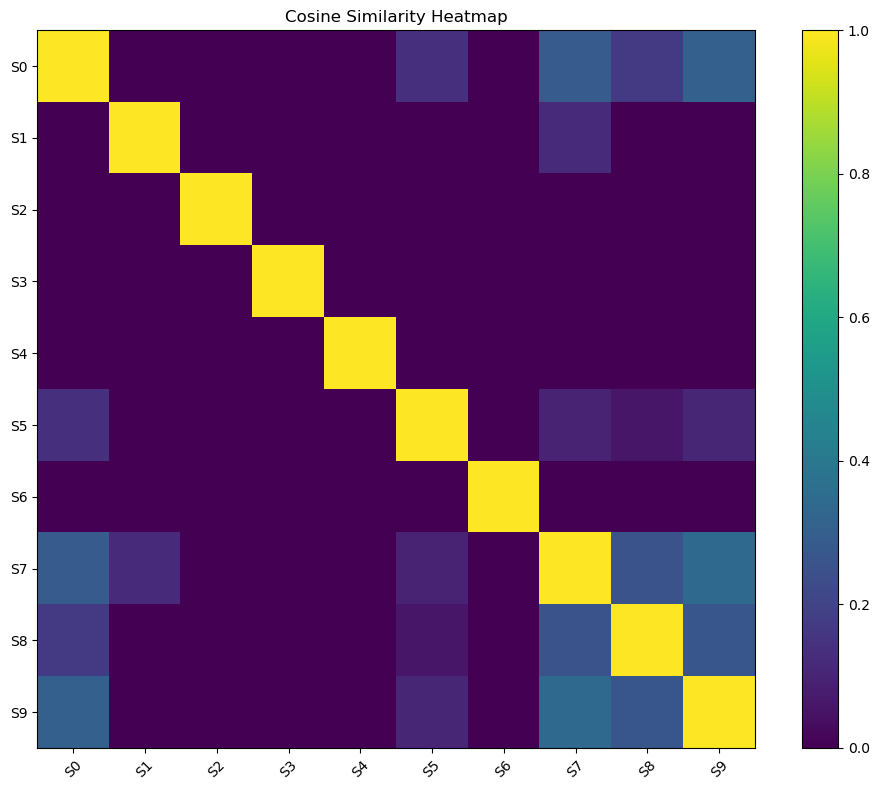

In [7]:
plt.figure(figsize=(10, 8))

heatmap = plt.imshow(similarity_matrix)

plt.colorbar(heatmap)

plt.xticks(range(len(sentences)),
           [f"S{i}" for i in range(len(sentences))],
           rotation=45)

plt.yticks(range(len(sentences)),
           [f"S{i}" for i in range(len(sentences))])

plt.title("Cosine Similarity Heatmap")

plt.tight_layout()

plt.show()